### 1 - Data Ingesion & Integration

In [1]:
import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, broadcast

In [2]:
#Dynamic Path Detection so it runs on all user environments
BASE_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(BASE_DIR, "data")

In [3]:
#Spark Initialization
spark = SparkSession.builder \
    .appName("BODS_Predictive_Engine") \
    .config("spark.hadoop.fs.defaultFS", "file:///") \
    .config("spark.driver.memory", "2g") \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/03 07:54:08 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
# Load files
df_cat = spark.read.csv(os.path.join(DATA_DIR, "overall_data_catalogue.csv"), header=True, inferSchema=True)
df_comp = spark.read.csv(os.path.join(DATA_DIR, "overall_compliance_report.csv"), header=True, inferSchema=True)

# Surgical Broadcast Join: Joining on Service Code (Catalogue) and Service Number (Compliance) <Multi Catalogue Ingestion>
df_unified = broadcast(df_cat).join(
    df_comp, 
    df_cat["Service Code"] == df_comp["Registration:Service Number"], 
    how="right"
)

print(f"Row count after surgical join: {df_unified.count()}")

Row count after surgical join: 103437


### 2 - Data Cleaning

In [5]:
# 1. Drop rows where critical compliance data is missing
df_cleaned = df_unified.fillna({'Service Code': 'UNKNOWN', 'Status': 'UNKNOWN'})

# 2. Impute missing numeric values (replace NULLs with 0)
df_cleaned = df_cleaned.fillna(0, subset=["% AVL to Timetables feed matching score"])

# 3. Final validation of record count
final_count = df_cleaned.count()
print(f"### **Final Cleaned Record Count: {final_count}**")

### **Final Cleaned Record Count: 103437**


In [6]:
# PySpark optimization
#Repartitioning to match cluster configuration and optimizing down to a safe state

df_optimized = df_cleaned.repartition(4)

#In-memory caching to optimize downstream aggregations and disk-writes
df_optimized.cache()

print(f"Cached partition count: {df_optimized.rdd.getNumPartitions()}")

26/07/03 07:54:43 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
[Stage 15:>                                                         (0 + 4) / 4]

Cached partition count: 4


[Stage 15:===========================================>              (3 + 1) / 4]

### PySpark SQL Integration: Complex Aggregations


In [7]:
df_optimized.createOrReplaceTempView("v_compliance_ledger")

# Execute analytical query calculating average compliance scores by Operator
compliance_summary_df = spark.sql("""
    SELECT 
        `Operator`,
        COUNT(*) as total_services,
        ROUND(AVG(CAST(`% AVL to Timetables feed matching score` AS DOUBLE)), 2) as avg_matching_score
    FROM v_compliance_ledger
    GROUP BY `Operator`
    HAVING total_services > 100
    ORDER BY total_services DESC
""")

# Show the analytical output
compliance_summary_df.show(5, truncate=False)

[Stage 17:==============>                                           (1 + 3) / 4]

+-------------------------+--------------+------------------+
|Operator                 |total_services|avg_matching_score|
+-------------------------+--------------+------------------+
|Arriva UK Bus            |42887         |0.0               |
|Go-Ahead                 |23029         |0.0               |
|Ipswich Buses            |8734          |0.0               |
|NULL                     |7934          |0.0               |
|Nottingham City Transport|2514          |0.0               |
+-------------------------+--------------+------------------+
only showing top 5 rows



### 3 - Data Storage & Processing

In [8]:
import sqlite3
import pandas as pd

In [9]:
# 1. Intermediate Write using optimized source ptr
intermediate_path = os.path.join(DATA_DIR, "cleaned_checkpoint_csv")
df_optimized.write.mode("overwrite").option("header", "true").csv(intermediate_path)

In [10]:
# 2. Loading Relational Database
db_path = os.path.join(DATA_DIR, "bods_analytics.db")
df_checkpoint = spark.read.option("header", "true").csv(intermediate_path)

In [11]:
# Conversion to Pandas for native SQLite loading
pandas_df = df_checkpoint.toPandas()
conn = sqlite3.connect(db_path)
pandas_df.to_sql("operator_compliance", conn, if_exists="replace", index=False)

103437

In [12]:
# #3. Secure Query Interface (Writing parameterized queries to prevent SQL injection)
import os

# Open a fresh connection so the function can read the database file
db_path = os.path.join(DATA_DIR, "bods_analytics.db")
conn = sqlite3.connect(db_path)

def secure_search_operator(operator_name):
    query = 'SELECT * FROM operator_compliance WHERE "Operator" = ? LIMIT 5'
    cursor = conn.cursor()
    cursor.execute(query, (operator_name,))
    results = cursor.fetchall()  # Fetches the rows
    cursor.close()
    return results               # Passes the rows back to the variable

# Run the test query
test_results = secure_search_operator("Go-Ahead")
print(test_results)

# Safely close the connection after printing
conn.close()

[('Go-Ahead', '10.0', 'BHBC; BLUS; BTRI; CROP; CSLB; CSSO; DAMY; DBLU; DDIS; ETBU; EYMS; FAST; GAGL; GAHL; GAWY; GNEL; GONW; GOSW; KNCO; LCAG; LGEN; LONC; MBGA; METR; NATI; OEXP; OXBC; PLYC; PROC; PULH; SDMS; SVCT; SWWD; TDTR; TFCN; THTR; TOUR; UNBU; UNIL; WDBC', 'Timetables', 'inactive', '2021-09-30T22:07:48.350+05:45', 'remote_dataset_556_2021-09-30_16-01-39.zip', 'GNEL_65_GNEL6565_20210905_-_63b2136d-dc59-4367-833b-4187cda8acb6.xml', 'Go-Ahead_Chester-le-Street_Peterlee_20210306_9', '556.0', 'Bus', 'GNEL', '65', '65', None, 'true', '4.0', '2021-09-05', None, '0.0', None, 'PD0001111/43010009', '65', 'Registered', 'In Scope', 'Not Seasonal', 'National Express West Midlands', 'No', 'No', 'Published', 'Up to date', 'No', 'No', 'Yes', 'No', 'No', 'Published', 'Not Stale', 'Yes', '20441', 'BODS_PD0001111_43010009_20260531_22.xml', 'TNXB', '2026-05-19', '2027-05-19', '2026-05-31', None, '22488.0', 'FX-PI-01_UK_WACT_NETWORK-FARE_nNetwork-nDaytripper-Ch_2026-03-06_2023-01-01_9d27.xml', '2026

### 4 - EDA

=== Requirement 1 & 3: Large-Scale Exploration & Profiling ===


+-------+------------------------+--------+------------+---------------------------------------+
|summary|Operator                |Status  |Scope Status|% AVL to Timetables feed matching score|
+-------+------------------------+--------+------------+---------------------------------------+
|count  |95503                   |103437  |103437      |103437                                 |
|mean   |NULL                    |NULL    |NULL        |0.0                                    |
|stddev |NULL                    |NULL    |NULL        |0.0                                    |
|min    |A-Line Coaches          |UNKNOWN |In Scope    |0.0                                    |
|max    |York Pullman Bus Company|inactive|Out of Scope|0.0                                    |
+-------+------------------------+--------+------------+---------------------------------------+

=== Requirement 1 & 2: Explicit Statistical Moments via .agg() ===
+----+------------------------+------------------+--------+

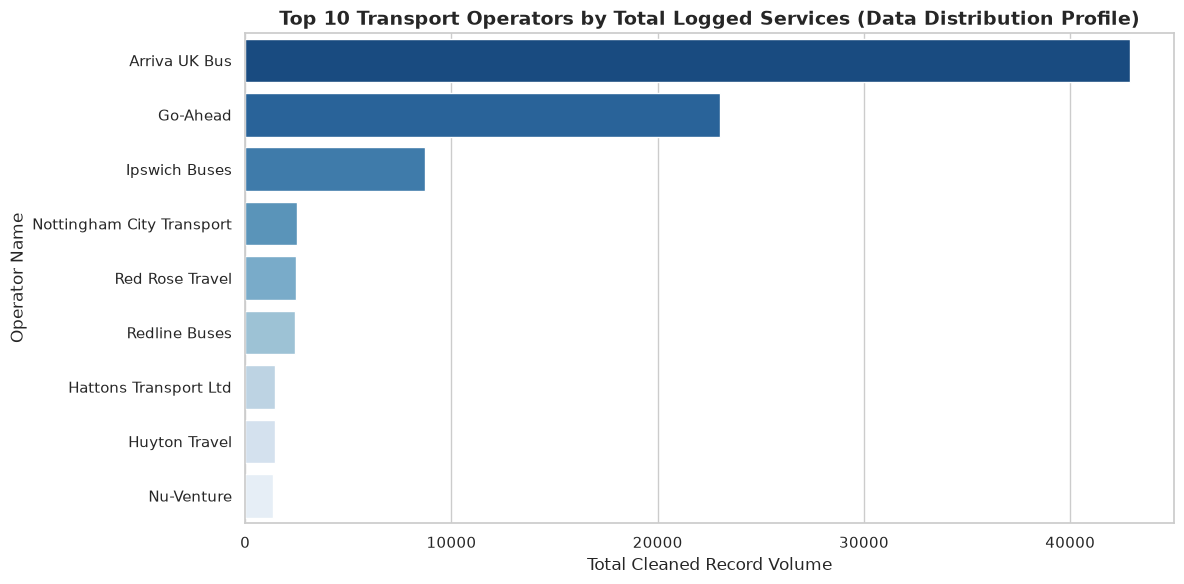

=== Feature Interaction: Compliance Status by Operational Scope ===


<Figure size 1000x500 with 0 Axes>

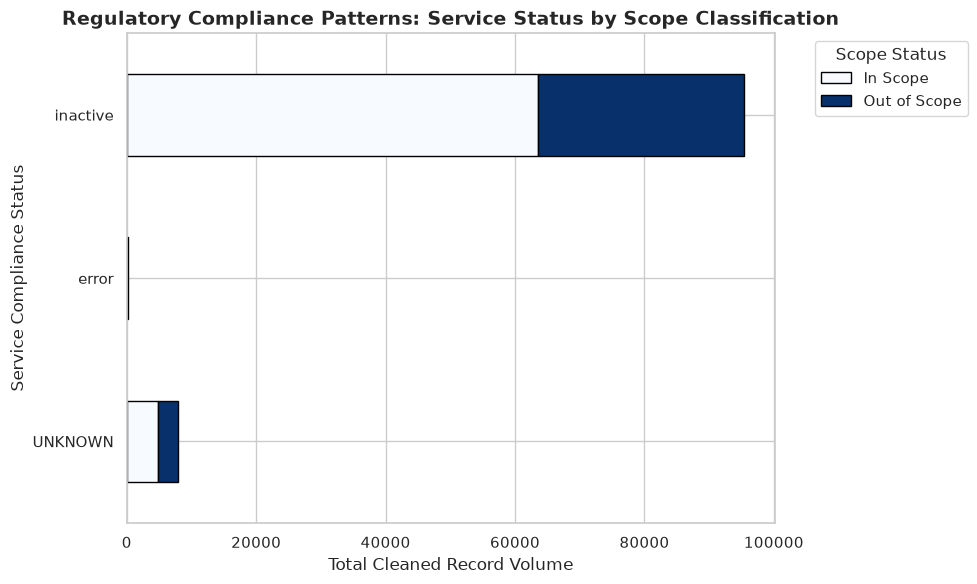

In [14]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col, mean, stddev, skewness, kurtosis, percentile_approx

sns.set_theme(style="whitegrid")

operator_col = "Operator"
status_col = "Status"
scope_col = "Scope Status"
score_col = "% AVL to Timetables feed matching score"

print("=== Requirement 1 & 3: Large-Scale Exploration & Profiling ===")
summary_df = df_optimized.select(col(operator_col), col(status_col), col(scope_col), col(score_col)).summary("count", "mean", "stddev", "min", "max")
summary_df.show(truncate=False)

print("=== Requirement 1 & 2: Explicit Statistical Moments via .agg() ===")
# Requirement 1 & 2: Explicitly demonstrating PySpark's .agg() and advanced metrics
statistical_moments_df = df_optimized.agg(
    mean(col(score_col)).alias("Mean"),
    percentile_approx(col(score_col), 0.5).alias("Median (50th Percentile)"),
    stddev(col(score_col)).alias("Standard_Deviation"),
    skewness(col(score_col)).alias("Skewness"),
    kurtosis(col(score_col)).alias("Kurtosis")
)
statistical_moments_df.show(truncate=False)

# Requirement 2: Calculate statistical outlier thresholds via IQR
operator_counts = df_optimized.groupby(col(operator_col)).count()
quantiles = operator_counts.approxQuantile("count", [0.25, 0.50, 0.75], 0.05)
q1, median_val, q3 = quantiles[0], quantiles[1], quantiles[2]
iqr = q3 - q1
upper_bound = q3 + (1.5 * iqr)

print(f"IQR Summary Stats -> Q1: {q1}, Median: {median_val}, Q3: {q3}")
print(f"IQR Upper Threshold: Operators with > {upper_bound:.2f} logged records are volume outliers.")
outlier_count = operator_counts.filter(col("count") > upper_bound).count()
print(f"Total Outlier Operators Identified: {outlier_count}\n")

# Requirement 5: Demonstrate data distributions, correlations, and patterns relevant to your business problem
top_operators_spark = df_optimized.groupby(col(operator_col)) \
    .count() \
    .orderBy(col("count").desc()) \
    .limit(10)

# Requirement 4: Create visualisations using matplotlib/seaborn/plotly — convert to Pandas only at the final plotting step
pdf_operators = top_operators_spark.toPandas()

plt.figure(figsize=(12, 6))
sns.barplot(
    x="count", 
    y=operator_col, 
    data=pdf_operators, 
    palette="Blues_r", 
    hue=operator_col, 
    legend=False
)
plt.title("Top 10 Transport Operators by Total Logged Services (Data Distribution Profile)", fontsize=14, fontweight='bold')
plt.xlabel("Total Cleaned Record Volume", fontsize=12)
plt.ylabel("Operator Name", fontsize=12)
plt.tight_layout()

os.makedirs(os.path.join(BASE_DIR, "docs", "screenshots"), exist_ok=True)
plt.savefig(os.path.join(BASE_DIR, "docs", "screenshots", "eda_operator_distribution.png"))
plt.show()

# Requirement 5: Demonstrate data distributions, correlations, and patterns relevant to your business problem
print("=== Feature Interaction: Compliance Status by Operational Scope ===")
cross_tab_spark = df_optimized.crosstab("Status", "Scope Status")

# Requirement 4: Create visualisations using matplotlib/seaborn/plotly — convert to Pandas only at the final plotting step
pdf_cross_tab = cross_tab_spark.toPandas().set_index("Status_Scope Status")

plt.figure(figsize=(10, 5))
pdf_cross_tab.plot(kind="barh", stacked=True, cmap="Blues", figsize=(10, 6), edgecolor="black")
plt.title("Regulatory Compliance Patterns: Service Status by Scope Classification", fontsize=14, fontweight='bold')
plt.xlabel("Total Cleaned Record Volume", fontsize=12)
plt.ylabel("Service Compliance Status", fontsize=12)
plt.legend(title="Scope Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig(os.path.join(BASE_DIR, "docs", "screenshots", "eda_compliance_patterns.png"))
plt.show()

### Feature Engineering & ML Pipeline